# Stage 1 — Study Area Setup (Mole Creek + Statewide DEM)

Prototype-first workflow: build and test the method at Mole Creek before
scaling statewide. This notebook:

1. Loads the Stage 0 boundaries (already in EPSG:7855)
2. Clips the Karst Atlas and geology to Mole Creek
3. **Merges all 29 municipality DEM tiles into one statewide mosaic and
   reprojects it
4. Clips the Mole Creek DEM from that statewide mosaic, so the local and statewide DEMs are
   guaranteed to be on the same grid/nodata handling

Verified against the actual data (2026-09-28): Karst Atlas, geology, and
DEM are all natively **EPSG:28355 (GDA94/MGA55)**; everything here is
reprojected to **EPSG:7855 (GDA2020/MGA55)** to match the rest of the
project. Vector layers are kept as vectors — only the DEM is rasterised.

In [7]:
from pathlib import Path
import os
import glob

import geopandas as gpd
import numpy as np
import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
import matplotlib.pyplot as plt

TARGET_CRS = "EPSG:7855"  # GDA2020 / MGA Zone 55

inpath = Path(os.environ.get("AT3_DATA_DIR", "data"))
outpath = inpath / "Output_data"
outpath.mkdir(exist_ok=True)
raw = inpath / "Input_data"  # raw source datasets (Karst Atlas, DEM, geology, etc.)

## 1. Load Stage 0 boundaries

Already in EPSG:7855, no reprojection needed here.

In [8]:
tasmania = gpd.read_file(str(outpath / "tasmania_bounding_box_EPSG7855.gpkg"))
mole_creek = gpd.read_file(str(outpath / "mole_creek_bounding_box_EPSG7855.gpkg"))
print("Tasmania:", tasmania.crs, tasmania.total_bounds)
print("Mole Creek:", mole_creek.crs, mole_creek.total_bounds)

Tasmania: EPSG:7855 [ 227147.50537116 5156757.32770346  627112.17909398 5660623.90620166]
Mole Creek: EPSG:7855 [ 427095.73278163 5370570.65210096  481521.97028419 5410510.64910886]


## 2. Karst Atlas — clipped to Mole Creek

Confirmed fields (from the real shapefile): `KCATEGORY`, `KEXPOSED`,
`KCOVERED`, `KINTERSTR`, `KPROXCATCH`, `KDISTCATCH`, `KAVRAIN`, `KLITH`,
`KNAME`. `KCATEGORY` is the field for karst intensity reclassification
(Stage 2).

Load the full atlas once, keep polygon features, and save the statewide layer for Stage 7.2. Clip the Mole Creek layer from this same prepared polygon set.

Karst polygons in Mole Creek: 90
KCATEGORY
A    46
B    23
0    17
D     4
Name: count, dtype: int64


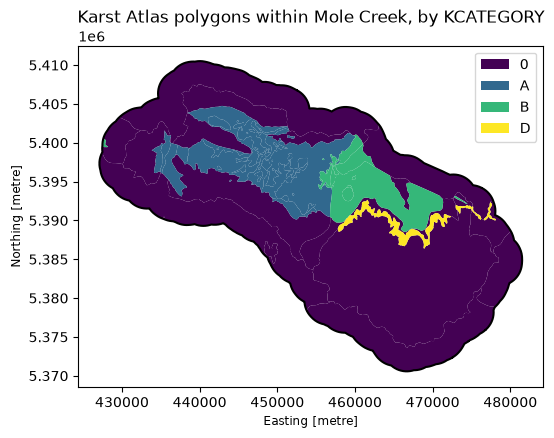

In [9]:
karst = gpd.read_file(str(raw / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp")).to_crs(TARGET_CRS)
karst_tas = karst[karst.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
karst_tas.to_file(outpath / "karst_tas_EPSG7855.gpkg", driver="GPKG")

karst_mc = gpd.clip(karst_tas, mole_creek)

print(f"Karst polygons in Mole Creek: {len(karst_mc)}")
print(karst_mc["KCATEGORY"].value_counts(dropna=False))

karst_mc.to_file(outpath / "karst_mc_EPSG7855.gpkg", driver="GPKG")

fig, ax = plt.subplots(figsize=(6, 6))
mole_creek.boundary.plot(ax=ax, color="black")
karst_mc.plot(ax=ax, column="KCATEGORY", legend=True, cmap="viridis")
plt.title("Karst Atlas polygons within Mole Creek, by KCATEGORY")
plt.show()

## 3. Geology — clipped to Mole Creek

`geology_units25k` is the layer with lithology info

/opt/anaconda3/envs/KGG375_AT3/lib/python3.11/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D MultiPolygon' is converted to 'MultiPolygon Z'
  return ogr_read(


Geology polygons in Mole Creek: 596


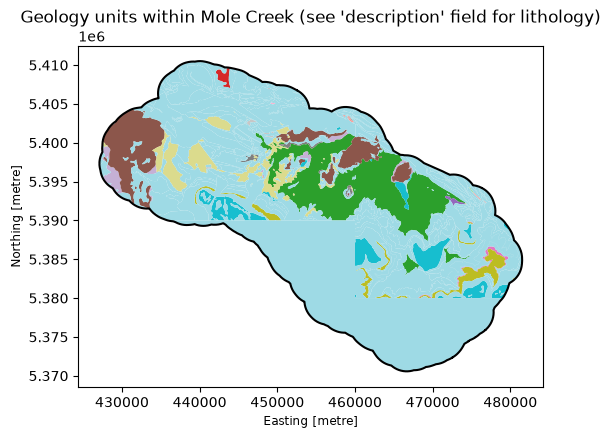

In [10]:
geology = gpd.read_file(str(raw / "geopackage/TasGeology25.gpkg"), layer="geology_units25k").to_crs(TARGET_CRS)
geology_mc = gpd.clip(geology, mole_creek)

print(f"Geology polygons in Mole Creek: {len(geology_mc)}")
geology_mc.to_file(outpath / "geology_mc_EPSG7855.gpkg", driver="GPKG")

fig, ax = plt.subplots(figsize=(6, 6))
mole_creek.boundary.plot(ax=ax, color="black")
geology_mc.plot(ax=ax, column="description", legend=False)
plt.title("Geology units within Mole Creek (see 'description' field for lithology)")
plt.show()

## 4. Statewide DEM — merge all 29 municipality tiles and reproject

**NoData handling matters** — the source `.asc` tiles declare `-9999.0`
as NoData; without explicitly carrying that through `merge()` and
`reproject()`, it gets treated as a real (very wrong) elevation value.

In [11]:
tiles = sorted(glob.glob(str(raw / "DEM/LIST_DEM_25M_*/*.asc")))
print(f"{len(tiles)} DEM tiles found")

srcs = [rasterio.open(t) for t in tiles]
dem_nodata = srcs[0].nodata
mosaic, mosaic_transform = merge(srcs, nodata=dem_nodata)
src_crs = srcs[0].crs
for s in srcs:
    s.close()
print(f"Merged mosaic shape: {mosaic.shape} ({mosaic.nbytes / 1e6:.0f} MB)")

dst_transform, width, height = calculate_default_transform(
    src_crs, TARGET_CRS, mosaic.shape[2], mosaic.shape[1],
    *rasterio.transform.array_bounds(mosaic.shape[1], mosaic.shape[2], mosaic_transform),
)
dem_tas = np.full((1, height, width), dem_nodata, dtype=mosaic.dtype)
reproject(
    source=mosaic[0], destination=dem_tas[0],
    src_transform=mosaic_transform, src_crs=src_crs,
    dst_transform=dst_transform, dst_crs=TARGET_CRS,
    src_nodata=dem_nodata, dst_nodata=dem_nodata,
    resampling=Resampling.bilinear,
)

dem_tas_profile = {
    "driver": "GTiff", "height": height, "width": width, "count": 1,
    "dtype": dem_tas.dtype, "crs": TARGET_CRS, "transform": dst_transform, "nodata": dem_nodata,
}
with rasterio.open(outpath / "dem_tas_EPSG7855.tif", "w", **dem_tas_profile) as dst:
    dst.write(dem_tas)

print(f"Statewide DEM written: {dem_tas.shape}, EPSG:7855")

29 DEM tiles found
Merged mosaic shape: (1, 20078, 15946) (1281 MB)
Statewide DEM written: (1, 20078, 15946), EPSG:7855


## 5. Clip the Mole Creek DEM from the statewide mosaic

This guarantees the local and statewide DEMs share the same 
grid alignment and NoData handling, which matters for the 
Stage 8 comparison later.

Mole Creek DEM clipped shape: (1, 1599, 2178)
Elevation range (m), NoData excluded: 110.0 - 1440.0


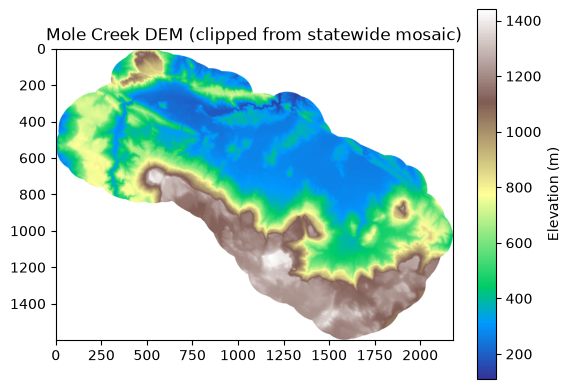

In [12]:
with rasterio.open(outpath / "dem_tas_EPSG7855.tif") as src:
    dem_mc, dem_mc_transform = mask(src, mole_creek.geometry, crop=True, nodata=dem_nodata)
    dem_mc_profile = src.profile.copy()

dem_mc_profile.update(height=dem_mc.shape[1], width=dem_mc.shape[2], transform=dem_mc_transform)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif", "w", **dem_mc_profile) as dst:
    dst.write(dem_mc)

dem_valid = np.ma.masked_equal(dem_mc, dem_nodata)
print("Mole Creek DEM clipped shape:", dem_mc.shape)
print("Elevation range (m), NoData excluded:", dem_valid.min(), "-", dem_valid.max())

plt.imshow(dem_valid[0], cmap="terrain")
plt.title("Mole Creek DEM (clipped from statewide mosaic)")
plt.colorbar(label="Elevation (m)")
plt.show()

## Stage 1 outputs

Written to `Output_data/` on the shared OneDrive, all EPSG:7855:

- `karst_mc_EPSG7855.gpkg` — Karst Atlas polygons, clipped to Mole Creek
- `karst_tas_EPSG7855.gpkg` - all statewide Karst Atlas polygon features
- `geology_mc_EPSG7855.gpkg` — geology units, clipped to Mole Creek
- `dem_tas_EPSG7855.tif` — **statewide** DEM mosaic (needed again in Stage 8)
- `dem_mc_EPSG7855.tif` — Mole Creek DEM, clipped from the statewide mosaic

`dem_mc_EPSG7855.tif` is the **raster template** for the Mole Creek
prototype; `dem_tas_EPSG7855.tif` is the template for the statewide
stage later.

**Next (Stage 2):** reclassify `KCATEGORY` into an ordinal karst
susceptibility score, and bring in `KEXPOSED`/`KCOVERED`/`KINTERSTR` for
the exposure-type layer.